# Load libraries and define some helpful functions

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from joblib import Parallel, delayed
from pathlib import Path
from scipy.stats import norm
from scipy.special import logsumexp
import re
import stan
import arviz as az

import nest_asyncio
nest_asyncio.apply()

# load prepared data from data_processing.ipynb
filename = "../Data/gb_energy_data_filled.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

## Posterior Plotters

In [2]:
def plot_trace_and_densities(fit, param_names, num_samples, n_chains):
    total_param_number = 0
    for param in param_names:
        if param not in fit.keys():
            print(param, "not present.")
            continue
        if fit[param].ndim == 3:
            total_param_number += fit[param].shape[0] * fit[param].shape[1]
        else:
            total_param_number += fit[param].shape[0]

    fig, axes = plt.subplots(total_param_number, 2, figsize=(8, 1.5*total_param_number))
    fig_index = 0
    for param in param_names:
        if fit[param].ndim==3:
            n_row = fit[param].shape[0]
            n_col = fit[param].shape[1]
            for i in range(n_row):
                for j in range(n_col):
                    param_name =  param + "[" + str(i) + ", " + str(j) +"]"
                    posterior_draws = fit[param][i,j].reshape(num_samples, n_chains).T

                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1

        elif fit[param].ndim==2:
            if fit[param].shape[0]>1:
                n_param = fit[param].shape[0]
                for param_index in range(n_param):
                    param_name = param+'[' + str(param_index) +']'
                    posterior_draws = fit[param][param_index].reshape(num_samples, n_chains).T
                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)

                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1
            else:
                posterior_draws = fit[param][0].reshape(num_samples, n_chains).T
                for chain_index in range(n_chains):
                    axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                    axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                axes[fig_index, 0].set_title(param)
                axes[fig_index, 1].set_title(param)
                fig_index += 1
    plt.tight_layout()
    plt.show()


def plot_posterior_scatter_matrix(fit, param_names, num_samples, n_chains, max_points=2000):
    posterior_draws = {}
    for param in param_names:
        if param not in fit.keys():
            print(f"Parameter {param} missing from fit.")
            continue
        arr = fit[param]
        if arr.ndim == 1:
            posterior_draws[param] = arr.reshape(num_samples, n_chains).T.flatten()
        else:
            for k in range(arr.shape[0]):
                posterior_draws[f"{param}[{k+1}]"] = arr[k].reshape(num_samples, n_chains).T.flatten()

    keys = list(posterior_draws.keys())
    if len(keys) == 0:
        return

    total_points = len(next(iter(posterior_draws.values())))
    sample_idx = np.random.choice(total_points, min(total_points, max_points), replace=False)

    n = len(keys)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    for i, xi in enumerate(keys):
        for j, yj in enumerate(keys):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior_draws[xi][sample_idx], bins=30, color='lightblue')
            else:
                ax.scatter(posterior_draws[yj][sample_idx],
                           posterior_draws[xi][sample_idx],
                           s=3, alpha=0.4)
            if i == n - 1:
                ax.set_xlabel(yj)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(xi)
            else:
                ax.set_yticklabels([])

    fig.suptitle("Posterior draw scatter matrix")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Posterior Sampling functions

In [23]:
def mean_function(parameter_values, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(parameter_values.shape[0]) if 'day_coef' in parameter_values.keys()[i]]
    hour_coef_index = [i for i in range(parameter_values.shape[0]) if 'hour_coef' in parameter_values.keys()[i]]

    day_coef_vals = np.insert(parameter_values.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(parameter_values.iloc[hour_coef_index].to_numpy(), 0 , 0.0)

    # f_1
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']]
    # f_2
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] + parameter_values['fourier_coef.1'] * np.cos(2*np.pi*X_data['time_year']) + parameter_values['fourier_coef.2'] * np.sin(2*np.pi*X_data['time_year'])
    # f_3
    mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] 
    for k in range(1,4):
        a1 = parameter_values['fourier_coef.1.' + str(k)]
        a2 = parameter_values['fourier_coef.2.' + str(k)]
        mean += a1* np.cos(2*np.pi*k*X_data['time_year']) + a2 * np.sin(2*np.pi*k*X_data['time_year'])
    return mean.to_numpy()

def posterior_det_mean(post_df: pd.DataFrame, X_data: pd.DataFrame):    
    n_post = post_df.shape[0]
    n_data = X_data.shape[0]
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        output[post_ind, :] = mean_function(post_df.iloc[post_ind,:], X_data)
    return output

def one_step_ahead_expected(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = len(y_data)
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        alpha = np.exp(-param_vals['theta'])
        det_mean = mean_function(param_vals, X_data)
        out = np.empty(n_data)
        out[0] = y_data[0]
        out[1:] = det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1]) + param_vals['mu_jump']*param_vals['p_jump']
        output[post_ind, :] = out

    return output

def posterior_jump_probability(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = len(y_data)
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        alpha = np.exp(-param_vals['theta'])
        out = np.empty(n_data)

        det_mean = mean_function(param_vals, X_data)
        m_nojump = det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1])
        m_jump = m_nojump + param_vals['mu_jump']

        sd_nojump = param_vals['sigma'] * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )
        sd_jump = np.sqrt( sd_nojump**2 + param_vals['sigma_jump']**2)

        jump_density = param_vals['p_jump'] * norm.pdf(y_data[1:], loc=m_jump, scale=sd_jump)
        nojump_density =  (1.0 - param_vals['p_jump']) * norm.pdf(y_data[1:], loc=m_nojump, scale=sd_nojump)

        out[0] = 0.0
        out[1:] = jump_density / (jump_density + nojump_density)
        output[post_ind, :] = out
    return output
        

def one_step_ahead_prediction(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = len(y_data)
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        alpha = np.exp(-param_vals['theta'])

        det_mean = mean_function(param_vals, X_data)
        out = np.empty(n_data)
        jump_indicator = np.random.binomial(1, param_vals['p_jump'], n_data-1)

        m = det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1]) + param_vals['mu_jump']*jump_indicator
        sd = np.sqrt( (param_vals['sigma']**2) * (1 - alpha*alpha) / (2*param_vals['theta']) + jump_indicator*(param_vals['sigma_jump']**2))

        out[0] = y_data[0]
        out[1:] = m + sd * np.random.normal(size=(n_data-1))
        output[post_ind, :] = out
    return output

def sample_mf_oujp_process(parameter_values: pd.Series, initial_value: float, X_data: pd.DataFrame, dt=1):
    n_steps = X_data.shape[0]
    alpha = np.exp(-parameter_values['theta']*dt)

    det_mean = mean_function(parameter_values, X_data)
    output = np.empty(n_steps)

    jump_indicator = np.random.binomial(1, parameter_values['p_jump'], size=n_steps)
    output[0] = initial_value
    OU_step_sd = np.sqrt( parameter_values['sigma'] * parameter_values['sigma'] * (1 - alpha*alpha) / (2*parameter_values['theta']) + parameter_values['sigma_jump']*parameter_values['sigma_jump'])
    random_steps = OU_step_sd * np.random.normal(size=n_steps) 
    for t in range(1, n_steps):
        output[t] = det_mean[t] + alpha * (output[t-1] - det_mean[t-1]) + jump_indicator[t] * parameter_values['mu_jump'] + random_steps[t]
    return output

def sample_posterior_predicitive(post: pd.DataFrame, y_initial_value: float, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = X_data.shape[0]
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        output[post_ind, ] = sample_mf_oujp_process(param_vals, 
                                                  y_initial_value, 
                                                  X_data)
    return output

def posterior_one_step_ahead_expectation(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = y_data.shape[0]
    output = np.empty((n_post, n_data-1))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        det_mean = mean_function(param_vals, X_data)
        out = np.empty(len(y_data))
        out[0] = y_data[0]
        out[1:] = det_mean[1:] + param_vals['alpha'] * (y_data[:-1] - det_mean[:-1]) + param_vals['p_jump']*param_vals['mu_jump']
        output[post_ind,] = out
        
    return output


## DataFrame Setup

In [4]:
training_window_size = 2*365 

final_month = data_gb.index.max().to_period("M")
validation_data = data_gb[data_gb.index.to_period("M") == final_month]
validation_data_start_date = min(validation_data.index)
validation_data_end_date = max(validation_data.index)
validation_data_days = np.unique(validation_data.index.to_period("D"))

training_window_start_date = validation_data_start_date - pd.Timedelta(days=training_window_size)
training_data = data_gb[(data_gb.index>=training_window_start_date) &
                        (data_gb.index<validation_data_start_date)]

print("Validation data time limits: " + str(validation_data_start_date) + ", " + str(validation_data_end_date))

Validation data time limits: 2020-09-01 00:00:00+00:00, 2020-09-30 23:00:00+00:00


/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20671/3974001527.py:3: UserWarning: Converting to Period representation will drop timezone information.
  final_month = data_gb.index.max().to_period("M")
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20671/3974001527.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data = data_gb[data_gb.index.to_period("M") == final_month]
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20671/3974001527.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data_days = np.unique(validation_data.index.to_period("D"))


In [5]:
training_data['price_day_ahead_filled']

utc_timestamp
2018-09-02 00:00:00+00:00    57.96
2018-09-02 01:00:00+00:00    59.96
2018-09-02 02:00:00+00:00    52.96
2018-09-02 03:00:00+00:00    51.92
2018-09-02 04:00:00+00:00    46.90
                             ...  
2020-08-31 19:00:00+00:00    59.84
2020-08-31 20:00:00+00:00    47.80
2020-08-31 21:00:00+00:00    41.22
2020-08-31 22:00:00+00:00    35.89
2020-08-31 23:00:00+00:00    34.71
Freq: h, Name: price_day_ahead_filled, Length: 17520, dtype: float64

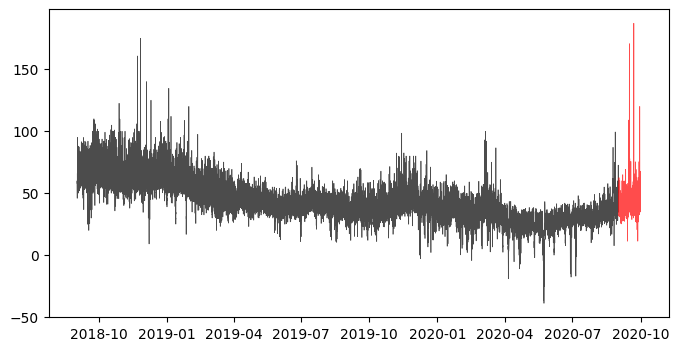

In [6]:
fig, axes = plt.subplots(1, figsize=(8, 4))

axes.plot(training_data.index, 
         training_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='black')
axes.plot(validation_data.index, 
         validation_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='red')

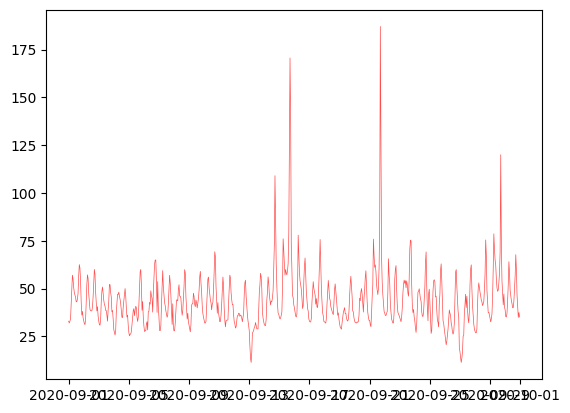

In [7]:
plt.plot(validation_data.index, 
         validation_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='red')

In [8]:
np.mean(training_data['price_day_ahead_filled']), np.std(training_data['price_day_ahead_filled'])

(np.float64(41.90260657318465), np.float64(16.396000943525074))

In [9]:
plot_df = data_gb.copy()
plot_df["hour"] = plot_df.index.hour
plot_df["day_name"] = pd.Categorical(
    plot_df.index.day_name(),
    categories=[1,2,3,4,5,6,7],
    ordered=True
)

/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_20671/1057846040.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  plot_df["day_name"] = pd.Categorical(


In [10]:
# Stan is 1-indexed, so add 1
day_idx   = (training_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx  = (training_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

day_idx_fore = (validation_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx_fore = (validation_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0], training_data.shape[0] + validation_data.shape[0]) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

# Fit model

## Run Inference

In [ ]:
stan_data = {
    # -- training data
    'T': len(training_data['price_day_ahead_filled']),
    'y': training_data['price_day_ahead_filled'].to_numpy(),
    'day_of_week_index': day_idx,
    'hour_index': hour_idx,
    'time_year': time_year_obs_data,
    'dt': 1,
    # -- validation data
    'T_fore': len(validation_data),
    'day_of_week_index_fore': day_idx_fore,
    'hour_index_fore': hour_idx_fore,
    
    # -- prior parameters
    'theta_mean': 2,
    'theta_sd': 1,
    'sigma_shape': 3 ** 2 / 1.0,
    'sigma_rate': 1 / 1.0,

    'p_jump_alpha': 1, 
    'p_jump_beta': 50,
    'mu_jump_mean': 0,
    'mu_jump_sd': 1,
    'sigma_jump_shape': 60 ** 2 / 10,
    'sigma_jump_rate': 60 / 10,

    'overall_mean_mu': np.mean(training_data['price_day_ahead_filled']),
    'overall_mean_sd': 5,
    'yearly_trend_mu': 0,
    'yearly_trend_sd': 10
}

In [11]:
stan_model_file = Path('./stan_files/levels_mf_oujp.stan')
model_code = stan_model_file.read_text()
posterior = stan.build(model_code, data=stan_data)

n_chains = 4
n_burnin = 500
n_posterior = 1000

fit = posterior.sample(num_chains=n_chains, num_samples=n_posterior, num_warmup=n_burnin)

Building...

In file included from /Users/b6072271/Library/Caches/httpstan/4.13.0/models/wpngp6vz/model_wpngp6vz.cpp:2:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/model/model_header.hpp:4:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math.hpp:19:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math/rev.hpp:4:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math/prim/fun/Eigen.hpp:23:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/Eigen/Sparse:26:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/Eigen/Spars

5 warnings generated.

Building: 11.2s, done.Messages from stanc:
Warning in '/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/httpstan_cn_x8y6g/model_wpngp6vz.stan', line 115, column 2: The
    parameter p_jump is on the left-hand side of more than one tilde
    statement.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the

## Inspect Posterior Chains

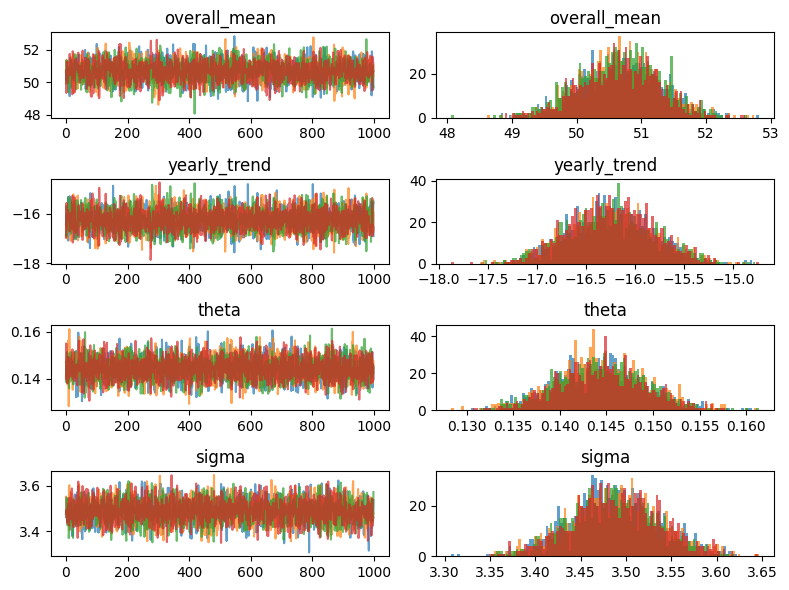

In [24]:
plot_trace_and_densities(fit, ['overall_mean', 'yearly_trend', 'theta', 'sigma'], n_posterior, n_chains)

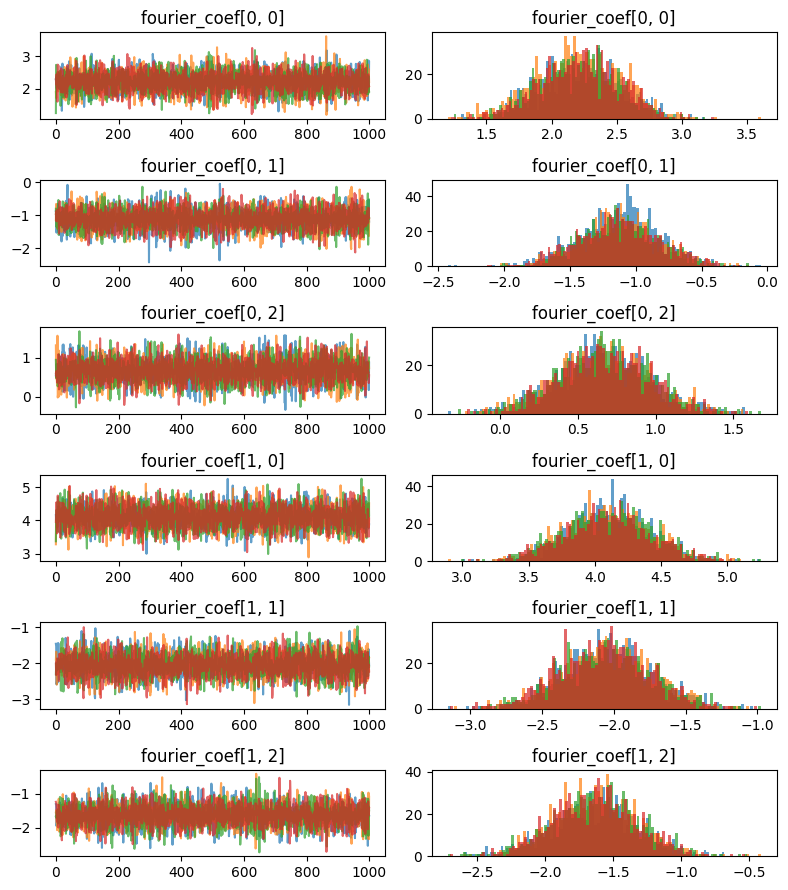

In [25]:
plot_trace_and_densities(fit, ['fourier_coef'], n_posterior, n_chains)

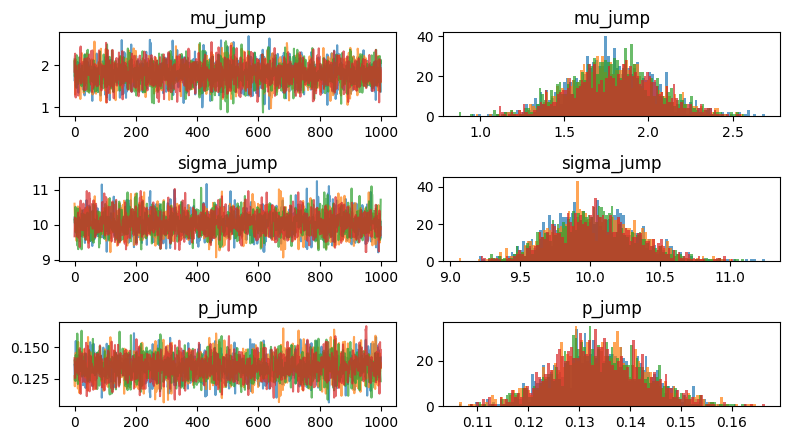

In [27]:
plot_trace_and_densities(fit, ['mu_jump', 'sigma_jump', 'p_jump'], n_posterior, n_chains)

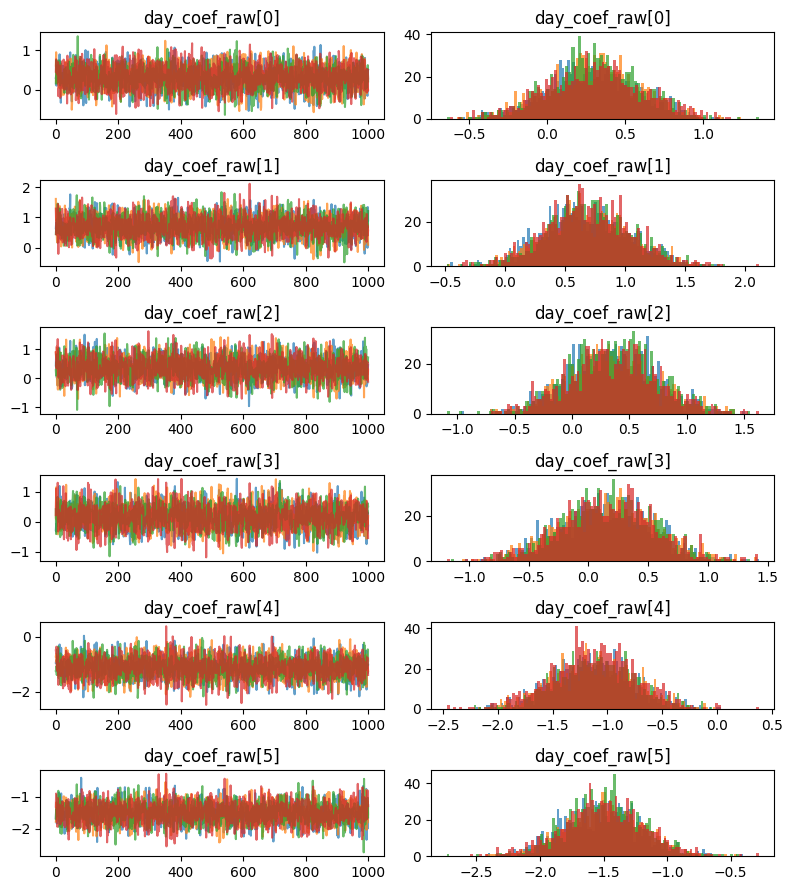

In [28]:
plot_trace_and_densities(fit, ['day_coef_raw'], n_posterior, n_chains) 

In [ ]:
plot_trace_and_densities(fit, ['hour_coef_raw'], n_posterior, n_chains)

In [ ]:
param_names = ['overall_mean', 'theta', 'sigma']

plot_posterior_scatter_matrix(fit, param_names, n_posterior, n_chains)

In [ ]:
plot_posterior_scatter_matrix(fit, ['fourier_coef'], n_posterior, n_chains)

In [ ]:
plot_posterior_scatter_matrix(fit, ['day_coef_raw'], n_posterior, n_chains)

In [ ]:
plot_posterior_scatter_matrix(fit, ['hour_coef_raw'], n_posterior, n_chains)

## Save Posterior Output

In [ ]:
# Save the posterior parameter draws
save_output = False

if save_output:
    fit_df = fit.to_frame()
    param_names = ['lp__', 'overall_mean', 'yearly_trend', 'theta', 'sigma', 'p_jump', 'mu_jump', 'sigma_jump']
    for i in range(1,7):
        param_names.append("day_coef_raw." + str(i))
    for i in range(1,24):
        param_names.append("hour_coef_raw." + str(i))
    for i in range(1,3):
        for j in range(1,4):
            param_names.append("fourier_coef." + str(i) + "." + str(j))
        
    print(param_names)
    post_to_save = fit_df[param_names]
    post_to_save.to_csv("./Posterior/oujp_parameters.csv")


# Posterior Predictive Plots

In [11]:
filename = "./Posterior/oujp_parameters.csv"
post_df = pd.read_csv(filename)

## Mean function

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].hist(post_df['overall_mean'], 100, density=True,
             color='lightblue', alpha=0.7)
axes[0].set_title("mu_0")
axes[1].hist(post_df['yearly_trend'], 100, density=True,
             color='lightblue', alpha=0.7)
axes[1].set_title("mu_1")


In [ ]:
overall_mean_exp = np.mean(post_df['overall_mean'])
yearly_trend_exp = np.mean(post_df['yearly_trend'])
overall_mean_exp, yearly_trend_exp

In [ ]:
plt.plot(training_data.index, training_data['price_day_ahead_filled'], 
         linestyle='--', linewidth=0.5, color='black')
plt.plot(training_data.index, overall_mean_exp + yearly_trend_exp*training_X_data['time_year'].to_numpy(), 
         linestyle='-', color='red', linewidth=2)

In [ ]:
detrended_price = training_data['price_day_ahead_filled'] - (overall_mean_exp + yearly_trend_exp*training_X_data['time_year'].to_numpy())

In [ ]:
plt.plot(training_data.index, detrended_price, 
         linestyle='--', linewidth=0.5, color='black')

In [ ]:
mm = mean_function(post_df.mean(axis=0), training_X_data)

plt.plot(training_data.index, training_data['price_day_ahead_filled'], 
         linestyle='--', linewidth=0.5, color='black')
plt.plot(training_data.index, mm, 
         linestyle='-', color='red', linewidth=2)

In [ ]:
mm = mean_function(post_df.mean(axis=0), training_X_data)

plt.plot(training_data.index, training_data['price_day_ahead_filled'] - mm, 
         linestyle='--', linewidth=0.5, color='black')

Text(0, 0.5, 'Spot Price £ / MW')

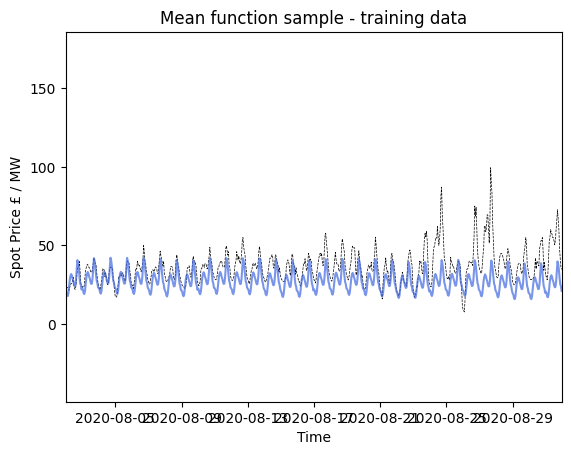

In [ ]:
mm = mean_function(post_df.iloc[100,:], training_X_data)

plt.plot(training_data.index, 
         training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', linewidth=0.5, color='black')
plt.plot(training_data.index, mean_function(post_df.iloc[0,:], training_X_data),
         color='royalblue', alpha=0.7)
plt.xlim([training_data.index[-30*24], training_data.index[-1]])
plt.title("Mean function sample - training data")
plt.xlabel('Time')
plt.ylabel('Spot Price (£/MWhr)')

## Posterior Predictives

In [13]:
# Include the final observation of the training data in the validation data, so that it can be conditioned upon
day_idx   = (training_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx  = (training_data.index.hour ).to_numpy(dtype=int)   # 0-23

day_idx_fore = (validation_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx_fore = (validation_data.index.hour).to_numpy(dtype=int)   # 0-23

day_idx_fore = np.insert(day_idx_fore, 0, day_idx[-1])
hour_idx_fore = np.insert(hour_idx_fore, 0, hour_idx[-1])

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0]-1, training_data.shape[0] + validation_data.shape[0]) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time': pd.date_range(training_data.index[-1], validation_data.index[-1], freq="h"),
    'price_day_ahead_filled': np.insert(validation_data['price_day_ahead_filled'].to_numpy(), 0, training_data['price_day_ahead_filled'].iloc[-1]),
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})


In [14]:
post_pred = sample_posterior_predicitive(post_df, training_data['GB_GBN_price_day_ahead'].iloc[0], training_X_data)
output_qnts = np.quantile(post_pred, [0.005, 0.995], axis=0)

Text(0, 0.5, 'Spot Price £/MWhr')

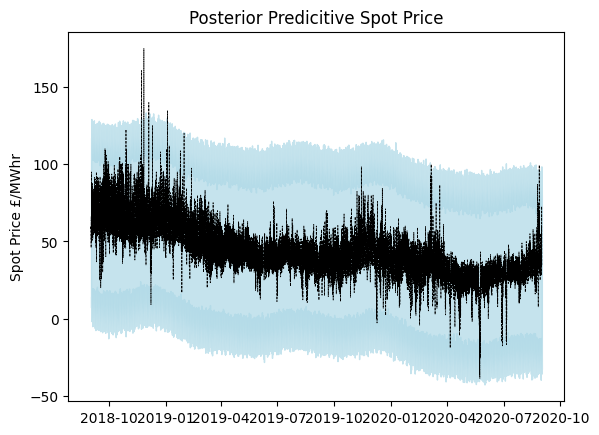

In [ ]:
plt.fill_between(training_data.index, 
                 output_qnts[0], 
                 output_qnts[1], 
                 color='lightblue', alpha=0.7)
plt.plot(training_data.index, training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.5)
plt.title("Posterior Predicitive Spot Price")
plt.ylabel("Spot Price (£/MWhr)")

In [24]:
post_pred_validation = sample_posterior_predicitive(post_df, validation_X_data['price_day_ahead_filled'][0], validation_X_data)
pred_forecast_qnts = np.quantile(post_pred_validation, [0.005, 0.995], axis=0)

forecast_mean = posterior_det_mean(post_df, validation_X_data)
forecast_mean_qnts = np.quantile(forecast_mean, [0.005, 0.995], axis=0)

Text(0, 0.5, 'Spot Price (£/MWhr)')

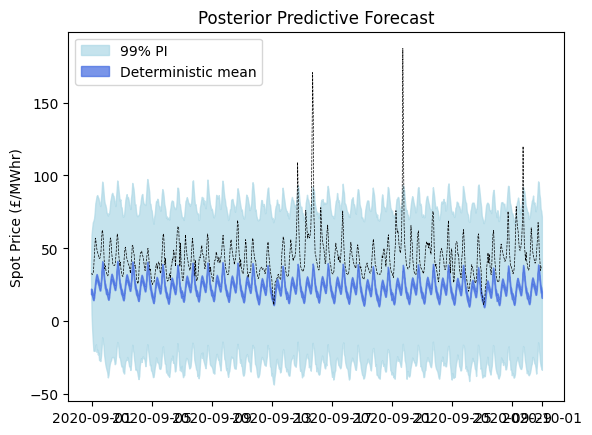

In [92]:
plt.fill_between(validation_X_data['time'], 
                 pred_forecast_qnts[0], 
                 pred_forecast_qnts[1], 
                 color='lightblue', alpha=0.7, label="99% PI")
plt.fill_between(validation_X_data['time'], 
                 forecast_mean_qnts[0], 
                 forecast_mean_qnts[1], 
                 color='royalblue', alpha=0.7, label="Deterministic mean")

plt.plot(validation_data.index, validation_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.5)
plt.legend()

plt.title("Posterior Predictive Forecast")
plt.ylabel("Spot Price (£/MWhr)")

In [25]:
one_step_pred = one_step_ahead_prediction(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)
one_step_pred_qnts = np.quantile(one_step_pred, [0.005, 0.25, 0.75, 0.995], axis=0)

one_step_expected = one_step_ahead_expected(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)
one_step_expected_qnts = np.quantile(one_step_expected, [0.005, 0.25, 0.75, 0.995], axis=0)

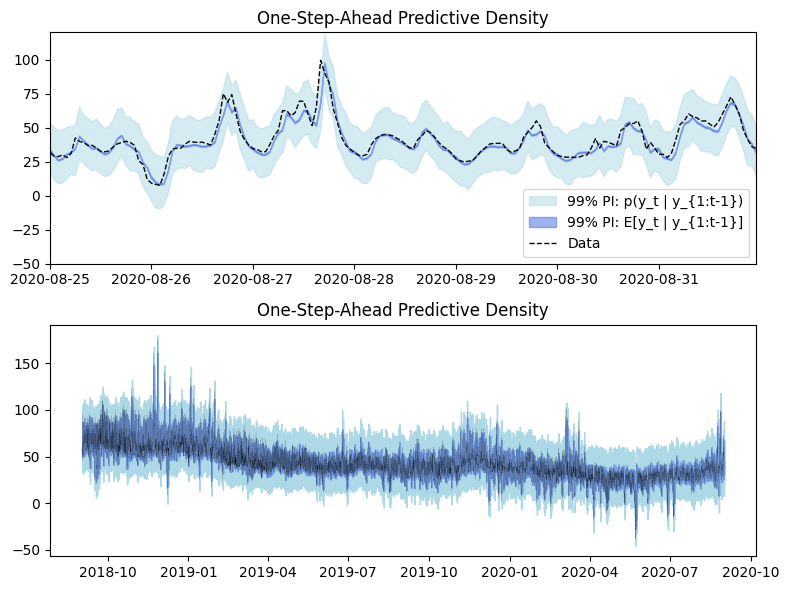

Mean width of 99% PI: 37.305334471839096


In [99]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI: p(y_t | y_{1:t-1})")
axes[0].fill_between(training_data.index, 
                one_step_expected_qnts[0], 
                one_step_expected_qnts[3], 
                alpha=0.5, color='royalblue', label="99% PI: E[y_t | y_{1:t-1}]")
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0,  label="Data")
axes[0].set_xlim([training_data.index[-7*24], training_data.index[-1]])
axes[0].set_ylim([-50,120])
axes[0].set_title("One-Step-Ahead Predictive Density")
axes[0].legend()

axes[1].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=1.0, color='lightblue',  label="99% PI")
axes[1].fill_between(training_data.index, 
                one_step_expected_qnts[0], 
                one_step_expected_qnts[3], 
                alpha=0.5, color='royalblue', label="50% PI")
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0,  label="Data")
axes[1].set_title("One-Step-Ahead Predictive Density")
plt.tight_layout()
plt.show()

quantile_diff = one_step_pred_qnts[3] - one_step_pred_qnts[0]
print("Mean width of 99% PI:", np.mean(quantile_diff))

Text(0.5, 1.0, 'Posterior predictive density, p(y_T | y_{1:t-1})')

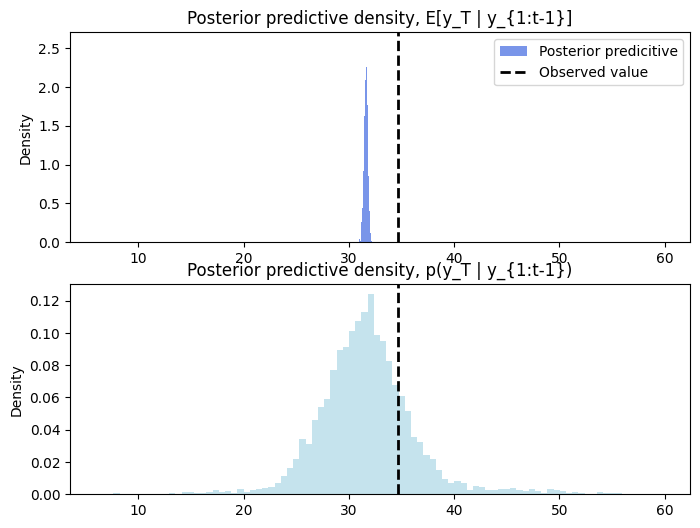

In [100]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=False)

ax1.hist(one_step_expected.T[-1], 100, density=True,
         color='royalblue', alpha=0.7, label="Posterior predicitive")
ax1.axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
ax1.set_ylabel("Density")
ax1.set_title("Posterior predictive density, E[y_T | y_{1:t-1}]")
ax1.set_xlim(min(one_step_pred.T[-1]), max(one_step_pred.T[-1]))
ax1.legend()

ax2.hist(one_step_pred.T[-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="Posterior predicitive");
ax2.axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
ax2.set_xlim(min(one_step_pred.T[-1]), max(one_step_pred.T[-1]))
ax2.set_ylabel("Density")
ax2.set_title("Posterior predictive density, p(y_T | y_{1:t-1})")

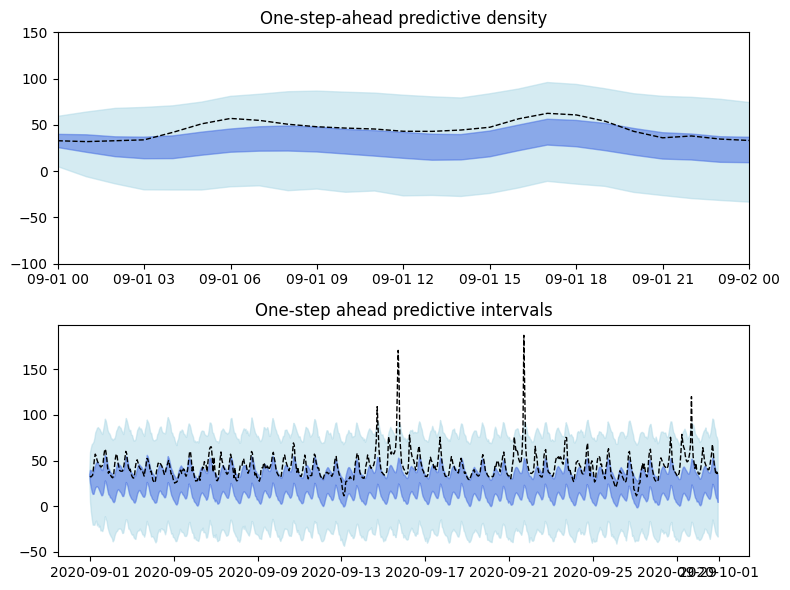

In [102]:

y_forecast_qnts = np.quantile(post_pred_validation, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(validation_X_data['time'], 
                y_forecast_qnts[0], 
                y_forecast_qnts[3], 
                alpha=0.5, color='lightblue')
axes[0].fill_between(validation_X_data['time'], 
                y_forecast_qnts[1], 
                y_forecast_qnts[2], 
                alpha=0.5, color='royalblue')
axes[0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[0].set_xlim([validation_data.index[0], validation_data.index[24]])
axes[0].set_ylim([-100,150])
axes[0].set_title("One-step-ahead predictive density")

axes[1].fill_between(validation_X_data['time'], 
                y_forecast_qnts[0], 
                y_forecast_qnts[3], 
                alpha=0.5, color='lightblue')
axes[1].fill_between(validation_X_data['time'], 
                y_forecast_qnts[1], 
                y_forecast_qnts[2], 
                alpha=0.5, color='royalblue')
axes[1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[1].set_title("One-step ahead predictive intervals")

plt.tight_layout()
plt.show()


## Jump Occurence

In [106]:
post_jump_prob = posterior_jump_probability(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)

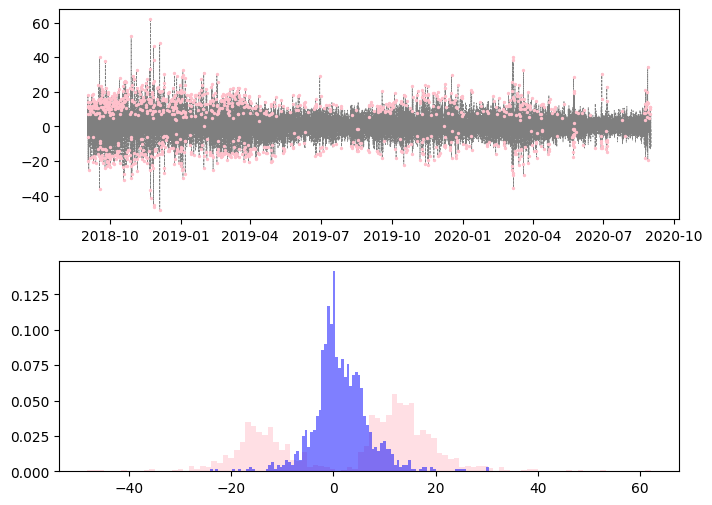

In [107]:
training_data['diff_price_day_ahead_filled'] = training_data['price_day_ahead_filled'].diff()

mean_jump_prob = post_jump_prob.mean(axis=0)
post_jump_ind = mean_jump_prob>0.5

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].plot(training_data.index, 
        training_data['diff_price_day_ahead_filled'], 
        color='black', linewidth=0.5, linestyle='--', alpha=0.5)
axes[0].scatter(training_data.index[np.where(post_jump_ind)[0]], 
                training_data['diff_price_day_ahead_filled'].iloc[np.where(post_jump_ind)[0]],
                color="pink", zorder=5, s=2, label="Detected jumps (P>0.5)")

axes[1].hist(training_data['diff_price_day_ahead_filled'].iloc[np.where(post_jump_ind)[0]], 100, density=True, 
             color='pink', alpha=0.5)
axes[1].hist(training_data['diff_price_day_ahead_filled'].iloc[~np.where(post_jump_ind)[0]], 100, density=True,
             color='blue', alpha=0.5);

In [ ]:
n_post = len(one_step_expected)
posterior_maee = np.empty(n_post) 
posterior_rmsee = np.empty(n_post)
posterior_mape = np.empty(n_post)
posterior_rmspe = np.empty(n_post)


for ind in range(n_post):
    maee = np.mean(abs(one_step_expected[ind,:] - training_data['GB_GBN_price_day_ahead']))
    posterior_maee[ind] = maee
    rmsee = np.mean( (one_step_expected[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmsee[ind] = rmsee

    mape = np.mean(abs(one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead']))
    posterior_mape[ind] = mape
    rmspe = np.mean( (one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmspe[ind] = rmspe

fig, axes = plt.subplots(2,2, figsize=(8, 5))

axes[0,0].hist(posterior_maee, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,0].set_title("MAEE Posterior")
axes[0,1].hist(posterior_rmsee, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,1].set_title("RSMEE Posterior")

axes[1,0].hist(posterior_mape, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,0].set_title("MAPE Posterior")
axes[1,1].hist(posterior_rmspe, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,1].set_title("RSMPE Posterior")

plt.tight_layout()
plt.show()


# Model Fit and Predictive Statistics

In [31]:
def posterior_loglik(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame, predictive=False):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    ll_mat = np.empty((n_post, n_data-1))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        alpha = np.exp(-param_vals['theta'])
        log_jump = np.log(param_vals['p_jump'])
        log_nojump = np.log(1.0 - param_vals['p_jump'])
        jump_sd = np.sqrt(param_vals['sigma']**2 + param_vals['sigma_jump']**2)
        
        det_mean = mean_function(param_vals, X_data)
        
        if predictive:
            pred_sample = sample_mf_oujp_process(param_vals, y_data[0], X_data)
            mean = det_mean[1:] + alpha * (pred_sample[:(n_data-1)] - det_mean[:(n_data-1)])
        else:
            mean = det_mean[1:] + alpha * (y_data[:(n_data-1)] - det_mean[:(n_data-1)])
        
        sd = param_vals['sigma'] * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )

        log_dens = np.empty((n_data-1, 2))
        log_dens[:,0] = log_jump + norm.logpdf(y_data[1:], loc=mean + param_vals['mu_jump'], scale=jump_sd)
        log_dens[:,1] = log_nojump + norm.logpdf(y_data[1:], loc=mean, scale=sd)

        ll_mat[post_ind, :] = logsumexp(log_dens, axis=1)

    return ll_mat

def log_predictive_score_from_loglik(loglik_mat: np.array):
    n_post = loglik_mat.shape[0]

    return logsumexp(loglik_mat, axis=0) - np.log(n_post)

def log_predictive_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]

    ll_mat = posterior_loglik(post, y_data, X_data, predictive=True)
    
    return logsumexp(ll_mat, axis=0) - np.log(n_post)
        
def waic_from_loglik(log_lik_matrix: np.array):  
    n_post = log_lik_matrix.shape[0]
    # sum of the logged mean likelihood (expected density) per observation
    log_expected_ll = logsumexp(log_lik_matrix, axis=0) - np.log(n_post) 
    mean_log_expected_ll = log_expected_ll.sum()

    # variance of log-likliehood per observation
    var_ll = np.var(log_lik_matrix, axis=0, ddof=1) 

    p_waic = 2 * (var_ll - log_expected_ll).sum()

    return p_waic

def waic(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    log_lik_matrix = posterior_loglik(post, y_data, X_data, predictive=False)

    return waic_from_loglik(log_lik_matrix)

def cts_ranked_probability_score_from_pred(pred: np.array, y_data: np.array):
    n_post = pred.shape[0]
    n_data = y_data.shape[0]

    scores = np.empty(n_data - 1)

    for data_ind in range(1, n_data):
        random_ind = np.random.randint(0, n_post, size=(2, n_post))
        abs_data_diff = abs( pred[:, data_ind] - y_data[data_ind] ).mean()
        abs_rand_diff = abs( pred[random_ind[0], data_ind] - pred[random_ind[1], data_ind] ).sum() / ( n_post*(n_post-1) )
        scores[data_ind-1] = abs_data_diff - 0.5 * abs_rand_diff

    return scores

def cts_ranked_probability_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    latent_sample, pred_sample = predictive_sample(post_df, y_data, training_X_data)
    return cts_ranked_probability_score_from_pred(pred_sample, y_data)

In [ ]:
obs_loglik_matrix = posterior_loglik(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)


mean ll: 7.183684378148169


In [ ]:
loglik = logsumexp(obs_loglik_matrix, axis=1)
print("mean ll:", np.mean(loglik)) # 7.183684378148169
print("SD ll:", np.std(loglik)) # 0.004418232473708421

mean ll: 7.183684378148169
SD ll: 0.004418232473708421


In [ ]:
log_score = log_predictive_score(post_df, validation_X_data['price_day_ahead_filled'].to_numpy(), validation_X_data)
print("mean LS:", np.mean(log_score)) # -4.527597867287041
print("range LS:", min(log_score), max(log_score)) # -43.01376025415529 -2.207047172556859

mean LS: -4.527597867287041
range LS: -43.01376025415529 -2.207047172556859


Text(0.5, 0, 'Log-Score')

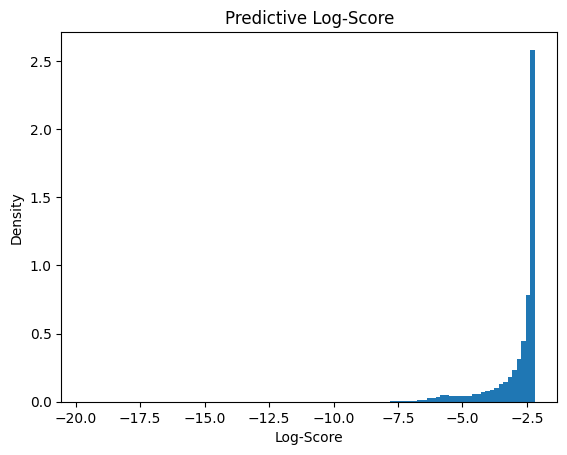

In [ ]:
plt.hist(log_score, 100, density=True)
plt.title("Predictive Log-Score")
plt.ylabel("Density")
plt.xlabel("Log-Score")

In [ ]:
p_waic = waic_from_loglik(obs_loglik_matrix)

In [ ]:
print("p-WIAC", p_waic) # 100596.70753950911
print("log10 p-WIAC", np.log10(p_waic)) #  5.00258376679523

p-WIAC 100596.70753950911
log10 p-WIAC 5.00258376679523


In [ ]:
# k = [hour] + [day] + [fourier] + [mean trend] + [stochastic]
number_of_parameters = 23 + 6 + 6 + 2 + 4
loglik = logsumexp(obs_loglik_matrix, axis=0)

BIC = number_of_parameters * np.log(training_data.shape[0]-1) - 2 * max(loglik)
print("BIC:", BIC) # 388.4180688775137

BIC: 388.4180688775137


In [12]:
post_df.columns

Index(['draws', 'lp__', 'overall_mean', 'yearly_trend', 'theta', 'sigma',
       'p_jump', 'mu_jump', 'sigma_jump', 'day_coef_raw.1', 'day_coef_raw.2',
       'day_coef_raw.3', 'day_coef_raw.4', 'day_coef_raw.5', 'day_coef_raw.6',
       'hour_coef_raw.1', 'hour_coef_raw.2', 'hour_coef_raw.3',
       'hour_coef_raw.4', 'hour_coef_raw.5', 'hour_coef_raw.6',
       'hour_coef_raw.7', 'hour_coef_raw.8', 'hour_coef_raw.9',
       'hour_coef_raw.10', 'hour_coef_raw.11', 'hour_coef_raw.12',
       'hour_coef_raw.13', 'hour_coef_raw.14', 'hour_coef_raw.15',
       'hour_coef_raw.16', 'hour_coef_raw.17', 'hour_coef_raw.18',
       'hour_coef_raw.19', 'hour_coef_raw.20', 'hour_coef_raw.21',
       'hour_coef_raw.22', 'hour_coef_raw.23', 'fourier_coef.1.1',
       'fourier_coef.1.2', 'fourier_coef.1.3', 'fourier_coef.2.1',
       'fourier_coef.2.2', 'fourier_coef.2.3'],
      dtype='str')

In [14]:
from arviz import ess
from arviz import summary
from arviz import rhat

In [18]:
post_ess_df = post_df.drop(columns=["draws", "lp__"])
post_ess_arr = post_ess_df.to_numpy()

In [19]:
post_ess_array = post_ess_arr.reshape(1000, 4, post_ess_arr.shape[1])
effective_sample_size = ess(post_ess_array, chain_axis=1, draw_axis=0)
print("EES:", min(effective_sample_size), max(effective_sample_size))

EES: 1384.1937269598209 5882.264050684369


In [16]:
effective_sample_size

array([2428.44370292, 3821.27597325, 5161.53183594, 3409.32898634,
       3208.15314058, 5550.62949256, 3589.78263228, 4100.65173983,
       3188.25291646, 2887.55171479, 3132.29009867, 3156.18026275,
       3805.77623754, 3052.38106536, 1921.73164647, 1720.52443952,
       1668.34098204, 1572.18966916, 1492.43435673, 1442.76131273,
       1411.43605177, 1411.85810135, 1384.19372696, 1405.26261399,
       1438.57453571, 1427.48331057, 1396.98327367, 1446.52444746,
       1507.58358638, 1538.2174739 , 1702.62711456, 1724.81041119,
       1765.95990529, 1900.46532093, 2547.69223411, 3766.64602396,
       5665.81443782, 5882.26405068, 4704.71590408, 5248.90103445,
       5606.29035827, 4966.54819228])

In [20]:
post_ess_df.columns[effective_sample_size<2000] 

Index(['hour_coef_raw.2', 'hour_coef_raw.3', 'hour_coef_raw.4',
       'hour_coef_raw.5', 'hour_coef_raw.6', 'hour_coef_raw.7',
       'hour_coef_raw.8', 'hour_coef_raw.9', 'hour_coef_raw.10',
       'hour_coef_raw.11', 'hour_coef_raw.12', 'hour_coef_raw.13',
       'hour_coef_raw.14', 'hour_coef_raw.15', 'hour_coef_raw.16',
       'hour_coef_raw.17', 'hour_coef_raw.18', 'hour_coef_raw.19',
       'hour_coef_raw.20', 'hour_coef_raw.21'],
      dtype='str')

In [21]:
effective_sample_size[effective_sample_size<2000]

array([1921.73164647, 1720.52443952, 1668.34098204, 1572.18966916,
       1492.43435673, 1442.76131273, 1411.43605177, 1411.85810135,
       1384.19372696, 1405.26261399, 1438.57453571, 1427.48331057,
       1396.98327367, 1446.52444746, 1507.58358638, 1538.2174739 ,
       1702.62711456, 1724.81041119, 1765.95990529, 1900.46532093])

In [ ]:
rhat(post_ess_array, chain_axis=1, draw_axis=0) < 1.05

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [ ]:
cprs_within_sample = cts_ranked_probability_score_from_pred(one_step_pred, training_data['price_day_ahead_filled'].to_numpy())
cprs_outof_sample = cts_ranked_probability_score_from_pred(post_pred_validation, validation_X_data['price_day_ahead_filled'])

print("Mean within-sample one-step-ahead:", cprs_within_sample.mean()) # 4.935907684324705
print("Mean out-of-sample predicted:", cprs_outof_sample.mean()) #23.735098687863108


Mean within-sample one-step-ahead: 4.935907684324705
Mean out-of-sample predicted: 23.735098687863108


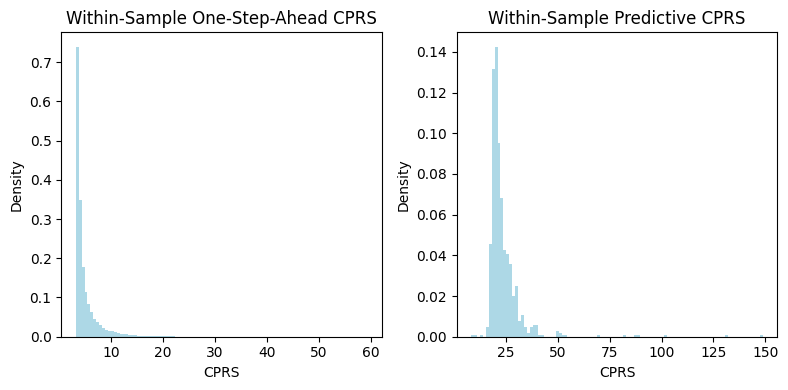

In [28]:
fig, axes = plt.subplots(1,2, figsize=(8, 4))

axes[0].hist(cprs_within_sample, 100, density=True, 
             color="lightblue")
axes[0].set_xlabel("CPRS")
axes[0].set_ylabel("Density")
axes[0].set_title("Within-Sample One-Step-Ahead CPRS")

axes[1].hist(cprs_outof_sample, 100, density=True, 
             color="lightblue");
axes[1].set_xlabel("CPRS")
axes[1].set_ylabel("Density")
axes[1].set_title("Within-Sample Predictive CPRS")

plt.tight_layout()

# blog plots

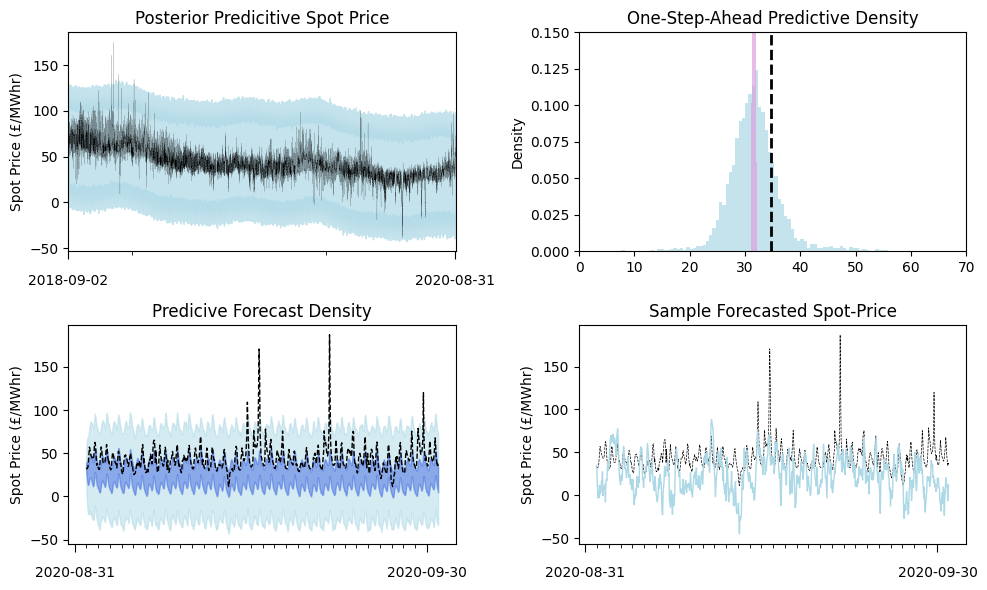

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=False)

axes[0,0].fill_between(training_data.index, 
                 output_qnts[0], 
                 output_qnts[1], 
                 color='lightblue', alpha=0.7)
axes[0,0].plot(training_data.index, training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.1)
axes[0,0].set_title("Posterior Predicitive Spot Price")
axes[0,0].set_ylabel("Spot Price (£/MWhr)")

# Show only the first and final day labels at their 00:00 observations
first_tick = training_data.index[0]
last_tick = training_data.index[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='YE'
)

axes[0,0].set_xlim(first_tick, last_tick)
axes[0,0].set_xticks([first_day_tick, last_day_tick])
axes[0,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[0,0].set_xticks(intermediate_day_ticks, minor=True)
axes[0,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[0,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[0,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


axes[0,1].hist(one_step_pred[:,-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="p()");
axes[0,1].hist(one_step_expected[:,-1], 100, density=True, 
             color='plum', alpha=0.7, label="E()");
axes[0,1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="y")
axes[0,1].set_ylim([0, 0.15])
axes[0,1].set_xlim([0,70])
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("One-Step-Ahead Predictive Density")

axes[1,0].fill_between(validation_X_data['time'], 
                y_forecast_qnts[0], 
                y_forecast_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1,0].fill_between(validation_X_data['time'], 
                y_forecast_qnts[1], 
                y_forecast_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1,0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1,0].set_title("Predicive Forecast Density")
axes[1,0].set_ylabel("Spot Price (£/MWhr)")

first_tick = validation_X_data['time'].iloc[0]
last_tick = validation_X_data['time'].iloc[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='D'
)

axes[1,0].set_xticks([first_day_tick, last_day_tick])
axes[1,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,0].set_xticks(intermediate_day_ticks, minor=True)
axes[1,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

axes[1,1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=0.5, linestyle='--', alpha=1.0, )
axes[1,1].plot(validation_X_data['time'], post_pred_validation[2], 
             color='lightblue', linewidth=1.0, linestyle='-', alpha=1.0,)
axes[1,1].set_title("Sample Forecasted Spot-Price")
axes[1,1].set_ylabel("Spot Price (£/MWhr)")

axes[1,1].set_xticks([first_day_tick, last_day_tick])
axes[1,1].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,1].set_xticks(intermediate_day_ticks, minor=True)
axes[1,1].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,1].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,1].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

plt.tight_layout()
